In [1]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects
import os
import numpy as np
import matplotlib.pyplot as plt
import h5py
import h5

In [2]:
sim = Simulation("TransmissionEfficiency")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# One full-frame exposure

sim["ObservingParameters/NumExposures"] = 1
sim["SubField/NumRows"] = 1
sim["SubField/NumColumns"] = 1

# Make sure no sources are located in the sub-field

sim["ObservingParameters/DecPointing"] = -sim["ObservingParameters/DecPointing"]

# Linear decrease from BOL to EOL

In [3]:
time = np.array([])
flux = np.array([])

deltaNumExposures = 100000
numExposures = sim["ObservingParameters/MissionDuration"] * 365.25 * 24 * 60 * 60 / 25

for beginExposure in range(0, 10000000,  deltaNumExposures):
    
    
    sim["ObservingParameters/BeginExposureNr"] = beginExposure
    output = sim.run(removeOutputFile = True)
    image = output.getImage(beginExposure)
    
    hfile = h5py.File(os.environ["PLATO_WORKDIR"] + "TransmissionEfficiency.hdf5", 'r')
    t = h5.h5get(hfile, ["ACS", "Time"], verbose = False)
    
    time = np.append(time, t)
    flux = np.append(flux, image[0][0])


2019-05-28 15:45:47 WARNING Simulation: no information about detected stars to write to HDF5
2019-05-28 15:45:47 WARNING Camera: No star positions to write to HDF5 file.


2019-05-28 15:45:48 WARNING Simulation: no information about detected stars to write to HDF5
2019-05-28 15:45:48 WARNING Camera: No star positions to write to HDF5 file.


2019-05-28 15:45:48 WARNING Simulation: no information about detected stars to write to HDF5
2019-05-28 15:45:48 WARNING Camera: No star positions to write to HDF5 file.


2019-05-28 15:45:48 WARNING Simulation: no information about detected stars to write to HDF5
2019-05-28 15:45:48 WARNING Camera: No star positions to write to HDF5 file.


2019-05-28 15:45:48 WARNING Simulation: no information about detected stars to write to HDF5
2019-05-28 15:45:48 WARNING Camera: No star positions to write to HDF5 file.


2019-05-28 15:45:48 WARNING Simulation: no information about detected stars to write to HDF5
2019-05-28 15:45:48 WARNING Camera: No star po


2019-05-28 15:45:56 WARNING Simulation: no information about detected stars to write to HDF5
2019-05-28 15:45:56 WARNING Camera: No star positions to write to HDF5 file.


2019-05-28 15:45:56 WARNING Simulation: no information about detected stars to write to HDF5
2019-05-28 15:45:56 WARNING Camera: No star positions to write to HDF5 file.


2019-05-28 15:45:57 WARNING Simulation: no information about detected stars to write to HDF5
2019-05-28 15:45:57 WARNING Camera: No star positions to write to HDF5 file.


2019-05-28 15:45:57 WARNING Simulation: no information about detected stars to write to HDF5
2019-05-28 15:45:57 WARNING Camera: No star positions to write to HDF5 file.


2019-05-28 15:45:57 WARNING Simulation: no information about detected stars to write to HDF5
2019-05-28 15:45:57 WARNING Camera: No star positions to write to HDF5 file.


2019-05-28 15:45:57 WARNING Simulation: no information about detected stars to write to HDF5
2019-05-28 15:45:57 WARNING Camera: No star po


2019-05-28 15:46:06 WARNING Simulation: no information about detected stars to write to HDF5
2019-05-28 15:46:06 WARNING Camera: No star positions to write to HDF5 file.


2019-05-28 15:46:06 WARNING Simulation: no information about detected stars to write to HDF5
2019-05-28 15:46:06 WARNING Camera: No star positions to write to HDF5 file.



In [4]:
hfile = h5py.File(os.environ["PLATO_WORKDIR"] + "TransmissionEfficiency.hdf5", 'r')

transmissionEfficiencyBOL = sim["Telescope/TransmissionEfficiency/BOL"]
transmissionEfficiencyEOL = sim["Telescope/TransmissionEfficiency/EOL"]

(0, 205124400.0)

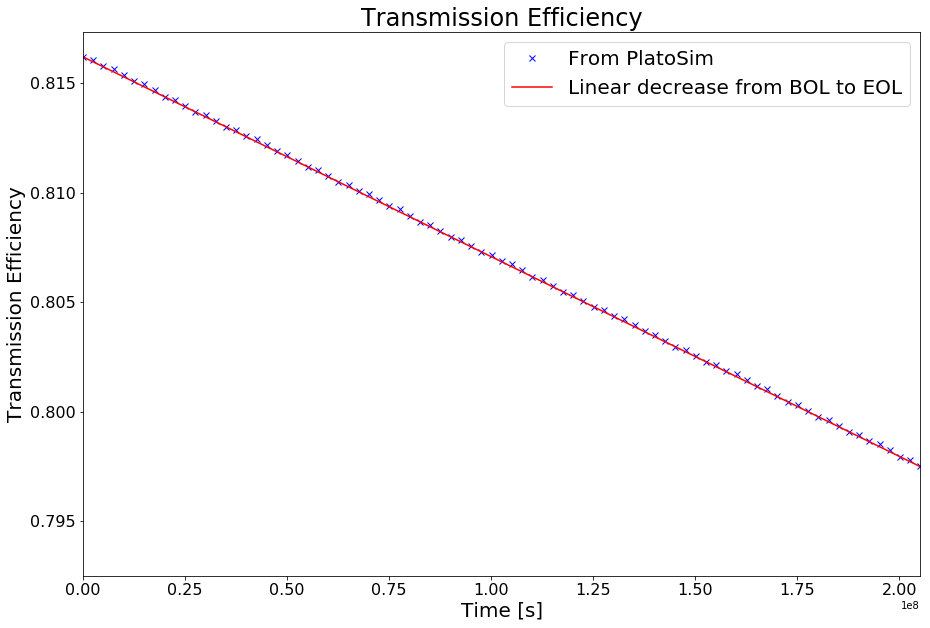

In [5]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(time, flux / flux[0] * transmissionEfficiencyBOL, "bx", label = "From PlatoSim")



#####################################################
# Expected linear decrease in transmission efficiency
#####################################################

bol = 0
eol = sim["ObservingParameters/MissionDuration"] * 365.25 * 24 * 60 * 60

plt.plot([bol, eol], [transmissionEfficiencyBOL, transmissionEfficiencyEOL], "r", label = "Linear decrease from BOL to EOL")



########
# Layout
########

plt.title("Transmission Efficiency", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Time [s]", fontsize = 20)
plt.ylabel("Transmission Efficiency", fontsize = 20)

plt.xlim([0, eol])